# 0.39 — When to close a theme position

Box 4 (Hotness) gives the entry date. This notebook is its mirror: **when do we get out?**

Three rules, each evaluated **only on the monthly rebalance days the backtest already stops on**,
using **only information available on that day**:

```
news      the theme's news flow has fallen back to its pre-entry normal
stop      the basket is more than X% below its own running peak
horizon   a fixed number of months has passed        (the baseline the others must beat)
```

Applying a rule does not change the backtest. It rewrites the monthly return series: every period
from the exit onward earns **cash** (13-week T-bill, the same series the Sharpe already uses)
instead of the basket. Held and exited runs therefore cover identical dates and period counts,
so every number below is directly comparable to 0.38.

**Two choices worth stating up front.**

1. The news rule measures a **level**, not acceleration. Entry uses the rolling z-score, which by
   construction returns to zero within its own 12-week window once a theme is *persistently* loud —
   it can detect an emergence but never the end of one. Instead:

   $$\text{level}(t) \;=\; \frac{\text{mean weekly hits over the last 12 weeks}}{\text{mean weekly hits over the 52 weeks before entry}}$$

   $1.0$ = news flow back to what it was before the theme existed.

2. The rule must be **armed** before it can fire: the level has to exceed the line at least once
   after entry. At the entry date the 12-week trailing mean is still mostly pre-theme, so the level
   sits at ~1.0 — an unarmed rule closes the position one month after opening it, on both themes,
   every time. "The story is over" presupposes it began.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import theme_backtest as bt
import theme_basket as tb
import theme_features as tf
import theme_exit as te

MIN_CAP, HOLD, END = 200.0, 1, "2025-12-31"     # unchanged from 0.38
GRAY = "#7a7a75"

THEMES = {"genAI":   dict(name="genai_2023-01-17",   start="2023-01-17", color="#eb6834"),
          "quantum": dict(name="quantum_2022-09-30", start="2022-09-30", color="#2a78d6")}

DECK8 = {"quantum": ["IONQ", "QUBT", "RGTI", "QBTS"],
         "genAI":   ["NVDA", "TRIP", "GOOG", "EA", "MYPS", "APPS",
                     "EXPE", "EBAY", "CRNC", "FFAI"]}

PROC = Path.cwd().parent / "data" / "processed"


def baskets(theme, top_n=10):
    """The three construction rules of 0.36, plus the list deck 8 actually traded."""
    n = THEMES[theme]["name"]
    b = pd.read_parquet(PROC / f"theme_basket_{n}.parquet")
    m = json.loads((PROC / f"theme_basket_{n}_manifest.json").read_text())
    out = {"1 count":    b.sort_values(["n_terms_hit", "per_1k_words"], ascending=False),
           "2 density":  b,
           "3 weighted": tb.rank_specificity(b, m)}
    d = {k: v.ticker.head(top_n).tolist() for k, v in out.items()}
    d["deck 8"] = DECK8[theme]
    return d


B = {t: baskets(t) for t in THEMES}
UNIVERSE = sorted({x for th in B.values() for v in th.values() for x in v} | {"SPY"})
px = bt.load_prices(UNIVERSE, verbose=False)

# the $200m floor, applied once at entry, exactly as 0.38 applies it
FILT = {}
for th in THEMES:
    names = list(dict.fromkeys([t for v in B[th].values() for t in v]))
    cap = tf.basket_sheet(names, THEMES[th]["start"], px, verbose=False) \
            .set_index("ticker")["cap_musd"].astype(float)
    FILT[th] = {k: [t for t in v if t in cap.index and np.isfinite(cap[t]) and cap[t] >= MIN_CAP]
                for k, v in B[th].items()}

DAYS = {th: bt._rebalance_days(px.index, THEMES[th]["start"], pd.Timestamp(END), HOLD)
        for th in THEMES}
print({th: f"{len(DAYS[th]) - 1} periods" for th in THEMES})

{'genAI': '36 periods', 'quantum': '40 periods'}


## 1 · The theme's own news, as a level

The vocabulary is the basket's own — the terms box 5 searched filings with — minus the terms its
manifest already flagged as generic. Matching is on the **exact phrases**: the corpus carries
n-gram terms, and splitting `quantum key distribution` into unigrams drags in *key*, *error* and
*distribution* and drowns the signal in off-theme news.

The chart runs from two years **before** detection (grey) through to the end of the window, so the
level can be read against the quiet period that defines it. The dotted line is the detection fire;
the two coloured lines are where the news rule and the 12-month rule would have sold.

genAI    vocab: alibaba, altman, baidu, chatgpt, chatgpt-like, chatgpt-style, ernie, netease, nvidia, openai
quantum  vocab: post-quantum, quantum, quantum annealing, quantum computer, quantum computing, quantum error correction, quantum key distribution, quantum sensing, quantum supremacy, qubit, superconducting qubit, trapped ion


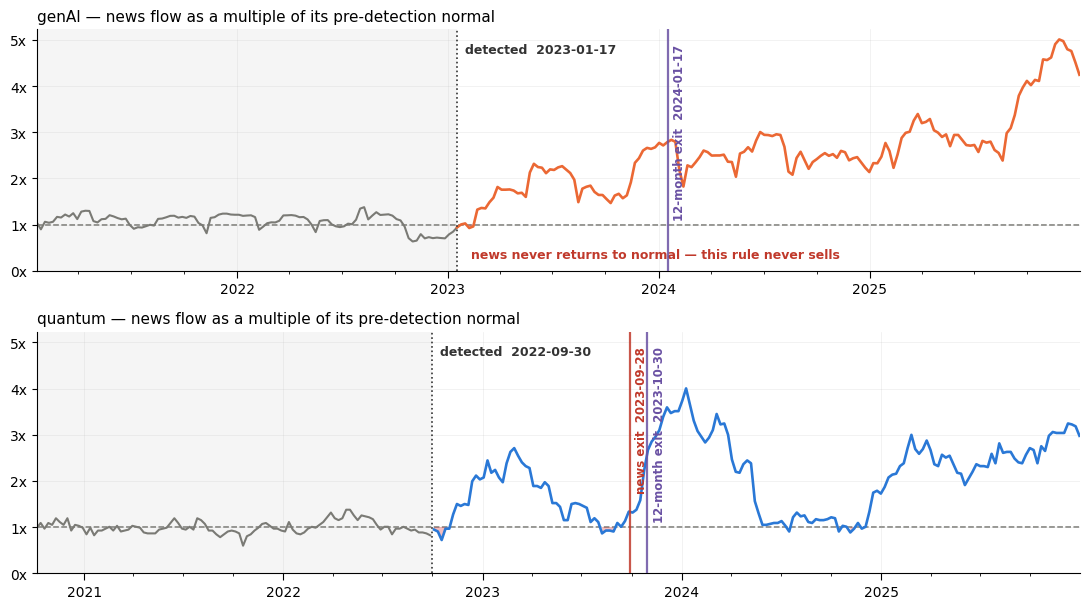

In [2]:
LEAD = 104          # weeks of history shown before the theme is detected

LEVEL = {}
for th, cfg in THEMES.items():
    hits = te.weekly_hits(cfg["name"], "2018-01-01", END)
    LEVEL[th] = te.news_level(hits, cfg["start"])
    print(f"{th:<8} vocab: {', '.join(te.theme_vocab(cfg['name']))}")

import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharey=True)
for ax, (th, cfg) in zip(axes, THEMES.items()):
    lvl, fire = LEVEL[th], pd.Timestamp(cfg["start"])
    s = lvl[(lvl.index >= fire - pd.Timedelta(weeks=LEAD)) & (lvl.index <= END)]
    pre, post = s[s.index <= fire], s[s.index >= fire]

    ax.axvspan(s.index[0], fire, color=GRAY, alpha=0.07, lw=0)
    ax.axhline(1.0, color=GRAY, lw=1.1, ls="--", zorder=1)
    ax.plot(pre.index, pre, color=GRAY, lw=1.5, zorder=2)
    ax.plot(post.index, post, color=cfg["color"], lw=1.9, zorder=3)
    ax.fill_between(post.index, 1.0, post.where(post < 1.0),
                    color="#d62728", alpha=0.30, lw=0, zorder=2)
    ax.axvline(fire, color="#333", lw=1.2, ls=":", zorder=4)
    ax.annotate(f"detected  {fire.date()}", (fire, 5.0), xytext=(6, -2),
                textcoords="offset points", va="top", fontsize=9,
                fontweight="bold", color="#333")

    # where the two rules we are keeping would have sold
    days = DAYS[th]
    marks = [("news exit", te.news_exit(lvl, days), "#c0392b"),
             ("12-month exit", te.horizon_exit(days, months=12), "#6a51a3")]
    for lab, d, col in marks:
        if d is None:
            continue
        ax.axvline(d, color=col, lw=1.6, alpha=0.85, zorder=4)
        # rotated along its own line: the two exits can fall a month apart
        ax.annotate(f"{lab}  {pd.Timestamp(d).date()}", (d, 4.92), xytext=(4, 0),
                    textcoords="offset points", rotation=90, va="top", ha="left",
                    fontsize=8.5, color=col, fontweight="bold")
    if marks[0][1] is None:
        ax.annotate("news never returns to normal — this rule never sells",
                    (fire, 0.28), xytext=(10, 0), textcoords="offset points",
                    fontsize=9, color="#c0392b", fontweight="bold")

    ax.set_xlim(s.index[0], pd.Timestamp(END))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))
    ax.tick_params(axis="x", which="major", length=5, labelsize=10)
    ax.tick_params(axis="x", which="minor", length=2.5)
    ax.set_ylim(0, None)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}x"))
    ax.grid(alpha=0.22, lw=0.5); ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{th} — news flow as a multiple of its pre-detection normal",
                 fontsize=11, loc="left")
plt.tight_layout(); plt.show()

## 2 · What each rule actually does

Below: the day each rule closes the position, per theme. The stop is basket-specific (it reads the
basket's own equity curve), so it is shown for the `deck 8` list as an example.

In [3]:
for th, cfg in THEMES.items():
    days, lvl = DAYS[th], LEVEL[th]
    curve = bt.rebalance_curve(px, B[th]["deck 8"], cfg["start"], END, months=HOLD)
    print(f"\n{th}  (entry {cfg['start']}, {len(days) - 1} monthly periods)")
    print(f"   news level: {lvl[lvl.index <= cfg['start']].iloc[-1]:.2f} at entry, "
          f"low of {lvl[lvl.index >= cfg['start']].min():.2f} "
          f"({lvl[lvl.index >= cfg['start']].idxmin().date()}), "
          f"{lvl.iloc[-1]:.2f} at the end")
    print(f"   news, no re-entry  -> {te.news_exit(lvl, days)}")
    st = te.news_state(lvl, days, reenter=True)
    print(f"   news, with re-entry -> in the market {int(st.sum())}/{len(st)} months")
    for dd in (0.20, 0.30, 0.40, 0.50):
        print(f"   stop {dd:.0%} (deck 8)      -> {te.stop_exit(curve, days, drawdown=dd)}")
    for m in (12, 24):
        print(f"   hold {m}m             -> {te.horizon_exit(days, months=m)}")


genAI  (entry 2023-01-17, 36 monthly periods)
   news level: 0.94 at entry, low of 0.93 (2023-02-07), 4.25 at the end
   news, no re-entry  -> None
   news, with re-entry -> in the market 36/36 months
   stop 20% (deck 8)      -> 2023-03-17 00:00:00
   stop 30% (deck 8)      -> 2023-10-17 00:00:00
   stop 40% (deck 8)      -> 2024-01-17 00:00:00
   stop 50% (deck 8)      -> 2024-04-17 00:00:00
   hold 12m             -> 2024-01-17 00:00:00
   hold 24m             -> 2025-01-17 00:00:00

quantum  (entry 2022-09-30, 40 monthly periods)
   news level: 0.82 at entry, low of 0.72 (2022-10-18), 2.98 at the end
   news, no re-entry  -> 2023-09-28 00:00:00
   news, with re-entry -> in the market 40/40 months
   stop 20% (deck 8)      -> 2022-11-30 00:00:00
   stop 30% (deck 8)      -> 2022-11-30 00:00:00
   stop 40% (deck 8)      -> 2022-12-30 00:00:00
   stop 50% (deck 8)      -> 2022-12-30 00:00:00
   hold 12m             -> 2023-10-30 00:00:00
   hold 24m             -> 2024-09-30 00:00:00

## 3 · Every rule, on all eight baskets

Same eight baskets as 0.38 — four construction rules, each as built and with the \$200m floor —
plus the index for reference.

In [4]:
RULES = ["hold", "news once-out", "news re-entry",
         "stop 20%", "stop 30%", "stop 40%", "stop 50%", "hold 12m", "hold 24m"]


def runs(theme, tickers):
    """The period-return series each rule produces from the same basket."""
    cfg, days, lvl = THEMES[theme], DAYS[theme], LEVEL[theme]
    r, _, _ = bt.rebalance_backtest(px, tickers, cfg["start"], END, months=HOLD)
    curve = bt.rebalance_curve(px, tickers, cfg["start"], END, months=HOLD)
    out = {"hold": r,
           "news once-out": te.apply_state(r, days, te.news_state(lvl, days, reenter=False)),
           "news re-entry": te.apply_state(r, days, te.news_state(lvl, days, reenter=True))}
    for dd in (0.20, 0.30, 0.40, 0.50):
        out[f"stop {dd:.0%}"] = te.apply_exit(r, days, te.stop_exit(curve, days, drawdown=dd))
    for m in (12, 24):
        out[f"hold {m}m"] = te.apply_exit(r, days, te.horizon_exit(days, months=m))
    return out


rows = []
for th in THEMES:
    for state, src in (("as built", B), ("+ floor", FILT)):
        for label, tk in src[th].items():
            if not tk:
                continue
            for rule, rr in runs(th, tk).items():
                rows.append(dict(theme=th, state=state, basket=label, rule=rule, n=len(tk),
                                 **te.exit_stats(rr, DAYS[th], HOLD)))
    r, _, _ = bt.rebalance_backtest(px, ["SPY"], THEMES[th]["start"], END, months=HOLD)
    rows.append(dict(theme=th, state="", basket="S&P 500", rule="hold", n=1,
                     **te.exit_stats(r, DAYS[th], HOLD)))
RES = pd.DataFrame(rows)


def pivot(theme, metric):
    p = (RES[RES.theme == theme]
         .pivot_table(index=["state", "basket"], columns="rule", values=metric, sort=False))
    return p[[c for c in RULES if c in p]]


for th in THEMES:
    for metric, fmt in (("compounded", "{:+.0%}".format), ("Sharpe ann", "{:.2f}".format)):
        print(f"\n=== {th} — {metric} ===")
        print(pivot(th, metric).to_string(float_format=fmt, na_rep="   -"))


=== genAI — compounded ===
rule                 hold  news once-out  news re-entry  stop 20%  stop 30%  stop 40%  stop 50%  hold 12m  hold 24m
state    basket                                                                                                    
as built 1 count    +148%          +148%          +148%      +12%       -9%      -19%     +148%      -16%     +102%
         2 density  +156%          +156%          +156%      +74%     +156%     +156%     +156%      +58%     +103%
         3 weighted +310%          +310%          +310%       +3%       -4%      +90%     +310%       -4%     +197%
         deck 8     +137%          +137%          +137%      +11%      -13%      -22%      -38%      -22%      +90%
+ floor  1 count    +108%          +108%          +108%      +62%      +45%     +108%     +108%      +21%      +63%
         2 density   +76%           +76%           +76%      +31%      +76%      +76%      +76%      +51%      +60%
         3 weighted +156%          +156%    

## 4 · Is the answer sensitive to the line we drew?

The news rule has one number in it (the level that counts as "back to normal"). The stop has one
(the distance). Both are swept here — if the conclusion only holds at one setting it is not a
conclusion.

In [5]:
sweep = []
for th, cfg in THEMES.items():
    days, lvl = DAYS[th], LEVEL[th]
    for thr in (1.0, 1.25, 1.5, 2.0):
        for reent in (False, True):
            st = te.news_state(lvl, days, threshold=thr, reenter=reent)
            row = dict(theme=th, threshold=thr,
                       mode="re-entry" if reent else "once-out",
                       months_in=f"{int(st.sum())}/{len(st)}")
            for state, src in (("as built", B), ("+ floor", FILT)):
                for label in ("1 count", "deck 8"):
                    tk = src[th][label]
                    if not tk:
                        continue
                    r, _, _ = bt.rebalance_backtest(px, tk, cfg["start"], END, months=HOLD)
                    s = te.exit_stats(te.apply_state(r, days, st), days, HOLD)
                    row[f"{label} {state}"] = s["Sharpe ann"]
            sweep.append(row)

SW = pd.DataFrame(sweep)
print("Sharpe by news threshold (hold = threshold never fires)")
print(SW.to_string(index=False, float_format="{:.2f}".format))

Sharpe by news threshold (hold = threshold never fires)
  theme  threshold     mode months_in  1 count as built  deck 8 as built  1 count + floor  deck 8 + floor
  genAI       1.00 once-out     36/36              0.54             0.51             0.79            0.71
  genAI       1.00 re-entry     36/36              0.54             0.51             0.79            0.71
  genAI       1.25 once-out     36/36              0.54             0.51             0.79            0.71
  genAI       1.25 re-entry     36/36              0.54             0.51             0.79            0.71
  genAI       1.50 once-out     36/36              0.54             0.51             0.79            0.71
  genAI       1.50 re-entry     36/36              0.54             0.51             0.79            0.71
  genAI       2.00 once-out      8/36             -0.20            -0.28             0.17            0.07
  genAI       2.00 re-entry     33/36              0.59             0.57             0.75       

In [6]:
# how often does a stop of each distance fire at all, and what does it cost?
cost = []
for th, cfg in THEMES.items():
    days = DAYS[th]
    for state, src in (("as built", B), ("+ floor", FILT)):
        for label, tk in src[th].items():
            if not tk:
                continue
            rr = runs(th, tk)
            base = te.exit_stats(rr["hold"], days, HOLD)["Sharpe ann"]
            for dd in ("stop 20%", "stop 30%", "stop 40%", "stop 50%"):
                s = te.exit_stats(rr[dd], days, HOLD)["Sharpe ann"]
                cost.append(dict(theme=th, state=state, basket=label, stop=dd,
                                 delta=s - base))
CO = pd.DataFrame(cost)
print("change in Sharpe vs holding, by stop distance")
print(CO.pivot_table(index="stop", columns="theme", values="delta",
                     aggfunc=["mean", "min", "max"]).to_string(float_format="{:+.2f}".format))
print(f"\nstops that improved Sharpe: {(CO.delta > 0).sum()} of {len(CO)}")

change in Sharpe vs holding, by stop distance
          mean           min           max        
theme    genAI quantum genAI quantum genAI quantum
stop                                              
stop 20% -0.59   -1.63 -0.89   -1.76 -0.24   -1.52
stop 30% -0.48   -1.45 -1.05   -1.76 +0.00   -0.82
stop 40% -0.35   -1.17 -1.27   -1.98 +0.00   -0.17
stop 50% -0.20   -0.69 -1.62   -1.85 +0.00   +0.00

stops that improved Sharpe: 0 of 64


## What the run says

**The pipeline now runs end-to-end with an exit box.** All three rules are implemented, evaluated
monthly, look-ahead-free, and applied identically to all eight baskets. That was the point of the
exercise. The result of the exercise is less comfortable.

**Nothing here beats holding by enough to be worth believing.** Of the 64 basket-and-stop
combinations, **none** improved the Sharpe ratio. Across the news-rule sweep, exactly two cells beat
holding — genAI as built, threshold 2.0, with re-entry (0.54 → 0.59 and 0.51 → 0.57) — and the same
setting *worsens* both filtered genAI baskets and all eight quantum ones. Two wins out of sixteen,
with no sign that survives the \$200m floor, is what noise looks like.

Both themes earned almost everything they earned in the last third of the window — quantum's entire
run is late 2024 onward, genAI's is 2024–25. Every rule that closes early gives that up.

**Rule by rule.**

- **News, no re-entry.** Correct in kind, ruinous in practice. It leaves genAI completely alone —
  the right call, since genAI's news flow never went quiet and ends the window above 4× its
  pre-entry normal. On quantum it fires in September 2023, into a six-week lull, and turns +668%
  into +32%. The news was back to 3.5× by that December. The v1 simplification — *close and stop* —
  is what converts a temporary quiet spell into a permanent loss.
- **News, with re-entry.** At the natural threshold (1.0) it is a no-op: on both themes the position
  is in the market every single month, because quantum's lull opened and closed *between* two
  rebalance dates. A monthly sampling of a four-week-confirmed weekly rule cannot see a six-week
  event. Raising the threshold makes it fire — and makes it worse, everywhere except the two cells
  noted above.
- **Stop-loss.** Incoherent with these baskets at any distance. A 20% stop on something with 30–54%
  monthly volatility is triggered by an ordinary month, and the damage does not shrink cleanly as
  the stop widens: it moves around non-monotonically, because the level a stop fires at carries no
  information about what comes next. Mean cost to Sharpe: −0.59 to −0.20 on genAI, −1.63 to −0.69
  on quantum.
- **Fixed horizon.** The honest baseline, and it loses to holding almost everywhere — closing at 12
  months costs more than closing at 24, which costs more than not closing.

**What this does *not* say.** Two themes, one entry each, one window. This is n = 2. Nothing here
establishes that theme exits don't work in general; it establishes that on the only two themes we
have, every simple exit fired before the payoff. A rule that cannot be separated from a coin flip on
two observations has not been tested, only demonstrated.

**Where it leaves the pipeline.** Box 7 exists, runs, and defaults to *don't*. The result worth
taking forward is the diagnostic rather than the rule: the news level is a genuine, readable
description of a theme's life — quantum's 2023 lull and its late-2024 re-acceleration are both
plainly visible in it, and both were real — and it belongs on a monitoring screen. It is not yet a
trading signal, and the reason is now measurable: at a monthly horizon the news and the payoff are
not synchronised closely enough for one to time the other.